# Delta Comparison: Analytic vs FFT

This notebook compares two methods for computing Black-Scholes Delta:
1. **Analytic formula** (closed-form)
2. **Carr-Madan FFT** (numerical)

In [7]:
import numpy as np
from scipy.stats import norm
import json
import matplotlib.pyplot as plt

import sys
from pathlib import Path

SRC = (Path.cwd() / ".." / "src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fourier_options.greeks.integrands import delta_integrand


#### Analytic Black-Scholes Delta

In [8]:
def bs_call_delta(params: dict[str, float], K: np.ndarray) -> np.ndarray:
    """
    Analytic Black–Scholes Delta for European calls (no dividends).
    
    Delta measures the sensitivity of option price to changes in the underlying
    stock price. Uses the closed-form formula Delta = N(d1).
    
    Required params:
        S0 (float): Initial stock price
        r (float): Risk-free interest rate
        sigma (float): Volatility (annualized)
        T (float): Time to maturity (in years)
        
    Args:
        params (dict): Model parameters
        K (np.ndarray): Strike prices
        
    Returns:
        Delta values for each strike
    """
    S0 = float(params["S0"])
    r = float(params["r"])
    sigma = float(params["sigma"])
    T = float(params["T"])

    K = np.asarray(K, dtype=float)

    # Edge case: at expiry, Delta is 1 if ITM, 0 otherwise
    if T <= 0:
        return (S0 > K).astype(float)

    # d1 from Black-Scholes formula
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    # Delta = N(d1) for call options
    return norm.cdf(d1)

#### FFT-Based Delta

In [9]:
def fft_delta_bs(
    params: dict[str, float],
    alpha: float = 1.25,
    N: int = 2**12,
    eta: float = 0.25,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Delta of a European call via Carr–Madan FFT in the Black–Scholes model.
    
    Computes Delta numerically using Fourier transform methods. Returns Delta
    on a grid of strikes, which can be interpolated to desired values.
    
    Required params:
        S0 (float): Initial stock price
        r (float): Risk-free interest rate
        sigma (float): Volatility (annualized)
        T (float): Time to maturity (in years)
        
    Args:
        params (dict): Model parameters
        alpha (float): Damping parameter for Carr-Madan formula
        N (int): Number of FFT points (power of 2)
        eta (float): Grid spacing in frequency domain
        
    Returns:
        Tuple of (strike grid, Delta values)
    """
    # Frequency grid
    j = np.arange(N)
    v = j * eta

    # Evaluate Delta integrand at each frequency
    psi = delta_integrand(v, params, alpha)

    # Log-strike grid spacing and offset
    lambd = 2.0 * np.pi / (N * eta)
    b = 0.5 * N * lambd

    # Build strike grid
    m = np.arange(N)
    k = -b + m * lambd
    K = np.exp(k)

    # Trapezoidal rule weights
    w = np.ones(N)
    w[0] = 0.5
    w[-1] = 0.5
    w *= eta

    # FFT computation
    fft_input = np.exp(1j * b * v) * psi * w
    fft_output = np.fft.fft(fft_input)

    # Undo damping and normalize
    Delta_vals = np.exp(-alpha * k) * fft_output.real / np.pi
    
    return K, Delta_vals

#### Load Parameters from Config

In [10]:
# Load parameters from config file
with open("../config.json", "r") as f:
    config = json.load(f)

params = {
    "S0": config["S0"],
    "r": config["r"],
    "sigma": config["sigma"],
    "T": config["T"],
}

alpha = config["alpha"]
eta = config["eta"]
N = config["N"]

print("Model Parameters:")
print(f"  S0 = {params['S0']}")
print(f"  r = {params['r']}")
print(f"  sigma = {params['sigma']}")
print(f"  T = {params['T']}")
print(f"\nFFT Settings:")
print(f"  alpha = {alpha}")
print(f"  eta = {eta}")
print(f"  N = {N}")

Model Parameters:
  S0 = 100
  r = 0.05
  sigma = 0.2
  T = 1.0

FFT Settings:
  alpha = 1.25
  eta = 0.25
  N = 4096


#### Compare methods

In [11]:
# ITM, ATM, OTM strikes
K_test = np.array([80.0, 100.0, 120.0])

# FFT Delta: compute on grid, then interpolate
K_grid, delta_grid = fft_delta_bs(params, alpha=alpha, N=N, eta=eta)
delta_fft = np.interp(np.log(K_test), np.log(K_grid), delta_grid)

# Analytic Delta
delta_bs = bs_call_delta(params, K_test)

# Compare results
print("K      Delta_FFT      Delta_BS      diff")
print("-------------------------------------------")
for K, d_fft, d_bs in zip(K_test, delta_fft, delta_bs):
    diff = d_fft - d_bs
    print(f"{K:6.1f}  {d_fft:11.6f}  {d_bs:11.6f}  {diff: .3e}")

K      Delta_FFT      Delta_BS      diff
-------------------------------------------
  80.0     0.928625     0.928637  -1.266e-05
 100.0     0.636815     0.636831  -1.543e-05
 120.0     0.287208     0.287192   1.652e-05


#### Visualiza Delta Across Strikes

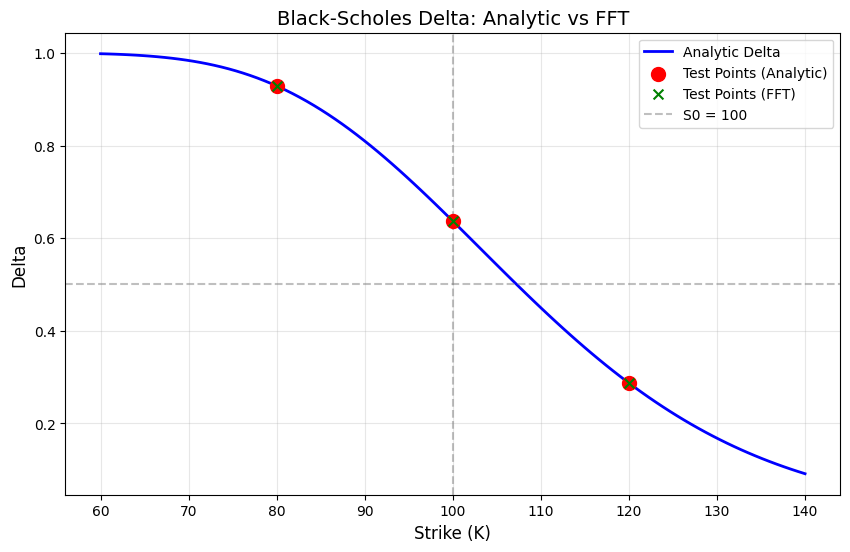

In [12]:
# Compute Delta for visualization
strikes_plot = np.linspace(60, 140, 100)
delta_analytic = bs_call_delta(params, strikes_plot)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(strikes_plot, delta_analytic, 'b-', label='Analytic Delta', linewidth=2)
plt.scatter(K_test, delta_bs, c='red', s=100, zorder=5, label='Test Points (Analytic)')
plt.scatter(K_test, delta_fft, c='green', s=50, marker='x', zorder=5, label='Test Points (FFT)')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=params['S0'], color='gray', linestyle='--', alpha=0.5, label=f"S0 = {params['S0']}")

plt.xlabel('Strike (K)', fontsize=12)
plt.ylabel('Delta', fontsize=12)
plt.title('Black-Scholes Delta: Analytic vs FFT', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()